In [1]:
from gauss import GPR
import utils
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
np.random.seed(42)
plt.rcParams.update({
    'font.size': 20,
    'font.family': 'serif', 
    'mathtext.fontset': 'stix',
    'axes.linewidth': 1.2,
    'xtick.major.size': 5, 
    'xtick.major.width': 1.2,
    'ytick.major.size': 5,
    'ytick.major.width': 1.2,
    'legend.fontsize': 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

Running Chi2 Analysis ...
Processing RBF...
Processing RQ...
Processing DSE...
Processing Matern32...
Processing Matern52...
Processing Matern72...
Processing Matern92...
Kernel   P_k/P_SE   P(SE < k)
RQ            2.232    0.309
DSE           1.839    0.352
Matern32      3.050    0.247
Matern52      2.554    0.281
Matern72      2.331    0.300
Matern92      2.131    0.319


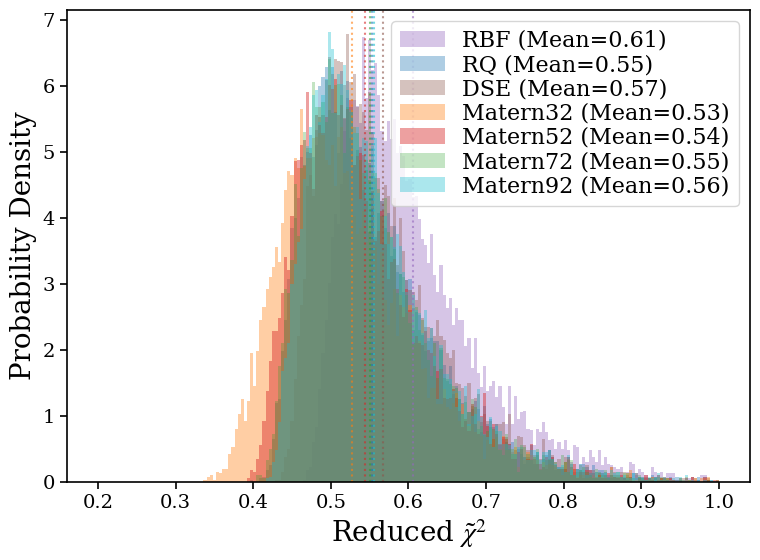

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import utils
import os
np.random.seed(42)
kernels = ['RBF','RQ','DSE','Matern32','Matern52','Matern72','Matern92']
colors = ["#9467bd60","#1f76b45c","#8c564b5c","#ff7e0e60","#d6272770","#2ca02c48","#17becf5c","#bcbd225c"]

data = np.loadtxt('data/cc.txt')
z_obs = data[:,0]
H_obs = data[:,1]
Cov_data = np.loadtxt('data/cc_cov.txt')

# sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
# z_sn, mB_obs, err_sn = sn_df['zHD'].values, sn_df['m_b_corr'].values, sn_df['m_b_corr_err_DIAG'].values
# mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")

# z_cp, mB_cp, mB_cp_std = np.loadtxt("output/mB_cp_summary.txt", unpack= True)
# mB_cp_cov = np.load("output/mB_cp_cov.npy")

results = {}
print("Running Chi2 Analysis ...")
for k in kernels:
    print(f"Processing {k}...")
    results[k] = utils.get_reduced_chi2_samples(z_obs,H_obs,Cov_data,k)

plt.figure(figsize=(8,6))
for k,c in zip(kernels,colors):
    mean_val = np.mean(results[k])
    plt.hist(results[k],bins=200,density=True,histtype='bar',lw=2,color=c,label=f'{k} (Mean={mean_val:.2f})',range=(0.2,1))
    plt.axvline(mean_val,color=c,ls=':',alpha=0.6)

plt.xlabel(r'Reduced $\tilde{\chi}^2$')
plt.ylabel('Probability Density')
# plt.title(r'Distribution of Reduced $\chi^2$ for different Kernels')
plt.legend(loc='upper right', fontsize=16, labelspacing=0.1)
plt.tight_layout()
plt.savefig('fig/kernel_chi2_distribution_hz.pdf', bbox_inches='tight')

ref_kernel = 'RBF'
P_ratio = {}

for k in kernels:
    if k == ref_kernel:
        continue
    Ni = np.sum(results[ref_kernel] < results[k])
    Nj = len(results[k]) - Ni
    P_ratio[k] = Nj / Ni

P_win = {}

for k in kernels:
    if k == ref_kernel:
        continue
    Ni = np.sum(results[ref_kernel] < results[k])
    Nj = len(results[k]) - Ni
    P_win[k] = 1.0 / (1.0 + Nj / Ni)
    
print("Kernel   P_k/P_SE   P(SE < k)")
for k in P_ratio:
    print(f"{k:10s} {P_ratio[k]:8.3f} {P_win[k]:8.3f}")



Running Chi2 Analysis ...
Processing RBF...
Processing RQ...
Processing DSE...
Processing Matern32...
Processing Matern52...
Processing Matern72...
Processing Matern92...
Kernel   P_k/P_SE   P(SE < k)
RQ            2.054    0.327
DSE           3.968    0.201
Matern32    525.316    0.002
Matern52     17.215    0.055
Matern72      7.475    0.118
Matern92      4.429    0.184


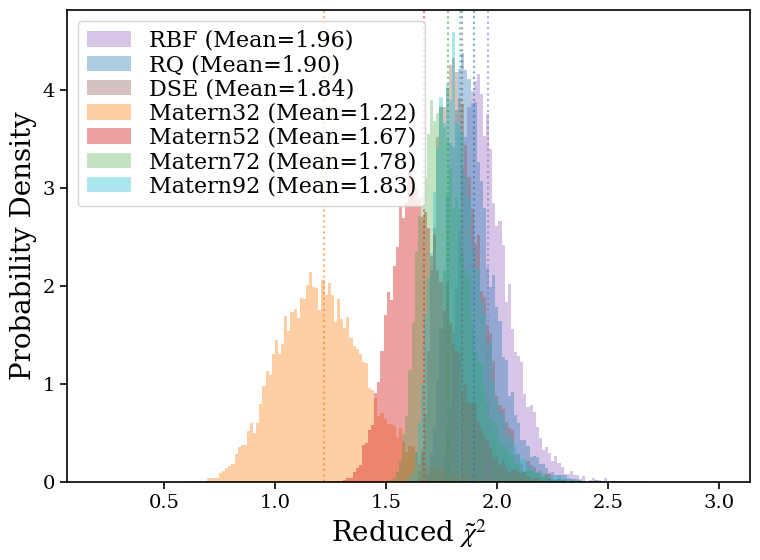

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import utils
import os
np.random.seed(42)
kernels = ['RBF','RQ','DSE','Matern32','Matern52','Matern72','Matern92']
colors = ["#9467bd60","#1f76b45c","#8c564b5c","#ff7e0e60","#d6272770","#2ca02c48","#17becf5c","#bcbd225c"]

z_cp, mB_cp, mB_cp_std = np.loadtxt("output/mB_cp_summary.txt", unpack= True)
mB_cp_cov = np.load("output/mB_cp_cov.npy")

results = {}
print("Running Chi2 Analysis ...")
for k in kernels:
    print(f"Processing {k}...")
    results[k] = utils.get_reduced_chi2_samples(np.log(z_cp),mB_cp,mB_cp_cov,k)

plt.figure(figsize=(8,6))
for k,c in zip(kernels,colors):
    mean_val = np.mean(results[k])
    plt.hist(results[k],bins=200,density=True,histtype='bar',lw=2,color=c,label=f'{k} (Mean={mean_val:.2f})',range=(0.2,3))
    plt.axvline(mean_val,color=c,ls=':',alpha=0.6)

plt.xlabel(r'Reduced $\tilde{\chi}^2$')
plt.ylabel('Probability Density')
# plt.title(r'Distribution of Reduced $\chi^2$ for different Kernels')
plt.legend(fontsize=16, labelspacing=0.1)
plt.tight_layout()
plt.savefig('fig/kernel_chi2_distribution_mB.pdf', bbox_inches='tight')

ref_kernel = 'RBF'
P_ratio = {}

for k in kernels:
    if k == ref_kernel:
        continue
    Ni = np.sum(results[ref_kernel] < results[k])
    Nj = len(results[k]) - Ni
    P_ratio[k] = Nj / Ni

P_win = {}

for k in kernels:
    if k == ref_kernel:
        continue
    Ni = np.sum(results[ref_kernel] < results[k])
    Nj = len(results[k]) - Ni
    P_win[k] = 1.0 / (1.0 + Nj / Ni)
    
print("Kernel   P_k/P_SE   P(SE < k)")
for k in P_ratio:
    print(f"{k:10s} {P_ratio[k]:8.3f} {P_win[k]:8.3f}")



In [4]:
# 1.对mB作高斯过程回归 cc和bao
sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn, mB_obs, err_sn = sn_df['zHD'].values, sn_df['m_b_corr'].values, sn_df['m_b_corr_err_DIAG'].values
mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")

# mask = (sn_df['IS_CALIBRATOR'] == 0) # 去掉了有chephid的样本
# z_sn = sn_df.loc[mask, 'zHD'].values
# mB_obs = sn_df.loc[mask, 'm_b_corr'].values

# idx_sn = sn_df.index[mask].values
# mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")
# mB_cov = mB_cov[np.ix_(idx_sn, idx_sn)]

# z_bao_dv, DV_rd, DV_rd_err = np.loadtxt('data/Combine_DV_rd.dat', unpack=True)
# z_bao_dm, DM_rd, DM_rd_err = np.loadtxt('data/Combine_DM_rd.dat', unpack=True)
# z_bao = np.concatenate((z_bao_dv, z_bao_dm)) #old dataset

z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)

z_cc, _, _ = np.loadtxt('data/cc.txt' , unpack=True)

In [3]:
# 训练GPR
gpr = GPR(l=1.0, sigma_f=100, kernel_name='matern', nu = 1.5) 
gpr.fit(np.log(z_sn), mB_obs, mB_cov, optimize_method='emcee') 

100%|██████████| 2000/2000 [1:34:32<00:00,  2.84s/it]


In [15]:
# 预测
mB_baomatch_mean, mB_baomatch_cov = gpr.predict_with_uncertainty(np.log(z_bao))
np.save('output/mB_baomatch_mean_GPR.npy', mB_baomatch_mean)
np.save('output/mB_baomatch_cov_GPR.npy', mB_baomatch_cov)

mB_ccmatch_mean, mB_ccmatch_cov = gpr.predict_with_uncertainty(np.log(z_cc))
np.save('output/mB_ccmatch_mean_GPR.npy', mB_ccmatch_mean)
np.save('output/mB_ccmatch_cov_GPR.npy', mB_ccmatch_cov)

Removed no burn in


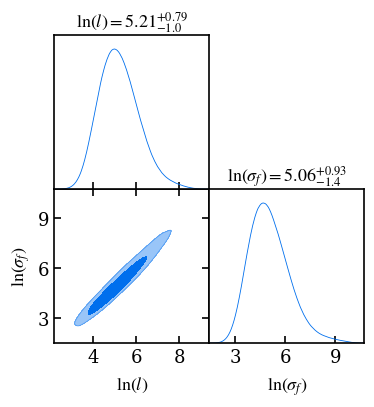

In [5]:
gpr = np.load('output/gpr_mB_withCephid_matern15.npy', allow_pickle=True).item()
from getdist import MCSamples, plots
%matplotlib inline
names  = ["ln_l", "ln_sigma_f"]
labels = [r"\ln(l)", r"\ln(\sigma_f)"]
gdsamples = MCSamples(
    samples=gpr.hyperparameter_samples,
    names=names,
    labels=labels
)
gdsamples.updateSettings({
    'smooth_scale_1D': 0.5,
    'smooth_scale_2D': 0.5
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize = g.settings.lab_fontsize = g.settings.title_limit_fontsize = g.settings.legend_fontsize = 16
g.triangle_plot(gdsamples, title_limit=1, filled=True)
plt.savefig('fig/hyperparameter_mB_gpr.pdf', bbox_inches='tight')

In [ ]:
# 保存核
# np.save('output/gpr_mB_withoutCephid.npy', gpr)
# np.save('output/gpr_mB_withCephid.npy', gpr)
# np.save('output/gpr_mB_withCephid_matern15.npy', gpr)

In [ ]:
# gpr = np.load('output/gpr_mB_withCephid_matern15.npy', allow_pickle=True).item()

In [6]:
from matplotlib import pyplot as plt
z_plot = np.linspace(0.005, 2.5, 1000)
mB_rec_GPR, mB_rec_GPR_cov = gpr.predict_with_uncertainty(np.log(z_plot))

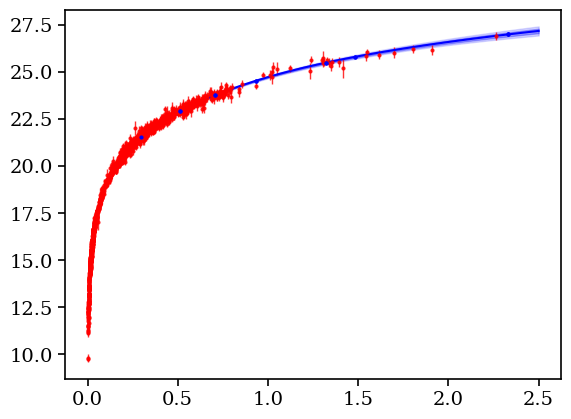

In [7]:
plt.errorbar(z_sn, mB_obs, yerr=np.sqrt(np.diag(mB_cov)), fmt='o', capsize=0, ms=2, elinewidth=1, color='red', alpha=0.8)
mB_baomatch_mean, mB_baomatch_cov = gpr.predict_with_uncertainty(np.log(z_bao))
plt.errorbar(z_bao, mB_baomatch_mean, yerr=np.sqrt(np.diag(mB_baomatch_cov)), fmt='o', capsize=0, ms=2, elinewidth=1, color='blue')
plt.fill_between(z_plot, mB_rec_GPR - np.sqrt(np.diag(mB_rec_GPR_cov)), mB_rec_GPR + np.sqrt(np.diag(mB_rec_GPR_cov)), color='blue', alpha=0.3)
plt.fill_between(z_plot, mB_rec_GPR - 2*np.sqrt(np.diag(mB_rec_GPR_cov)), mB_rec_GPR + 2*np.sqrt(np.diag(mB_rec_GPR_cov)), color='blue', alpha=0.15)
plt.plot(z_plot, mB_rec_GPR, color='blue')

In [8]:
np.sqrt(np.diag(mB_baomatch_cov))

array([0.00929336, 0.01311021, 0.01311021, 0.01712862, 0.01712862,
       0.02911106, 0.02911106, 0.04714799, 0.04714799, 0.05313949,
       0.05313949, 0.10735183, 0.10735183])

In [9]:
# 2.进行Hz的重构和z的匹配，以及hz推断的光度距离的计算
from gauss import GPR
import utils
import pandas as pd
import numpy as np
np.random.seed(42)
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt
z_plot = np.linspace(0.005, 2.5, 1000)

z_cc, H_obs, _= np.loadtxt('data/cc.txt', unpack=True)
H_cov = np.loadtxt('data/cc_cov.txt')
gpr = GPR(l=1.0, sigma_f=100, kernel_name='matern', nu=1.5) 
gpr.fit(z_cc, H_obs, H_cov, optimize_method='emcee') 
print(f"Optimized hyperparameters: l={gpr.l:.3f}, sigma_f={gpr.sigma_f:.3f}")


z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)
cc_baomatch_mean_GPR, cc_baomatch_cov_GPR = gpr.predict_with_uncertainty(z_bao)
np.save('output/cc_baomatch_mean_GPR.npy', cc_baomatch_mean_GPR)
np.save('output/cc_baomatch_cov_GPR.npy', cc_baomatch_cov_GPR)
# np.save('output/gpr_cc_matern15.npy', gpr)


100%|██████████| 2000/2000 [00:04<00:00, 427.07it/s]

Optimized hyperparameters: l=6.163, sigma_f=221.298


Removed no burn in


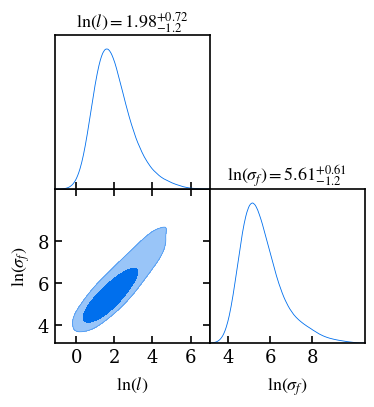

In [10]:
# gpr = np.load('output/gpr_cc_matern15.npy', allow_pickle=True).item()
from getdist import MCSamples, plots
%matplotlib inline
names  = ["ln_l", "ln_sigma_f"]
labels = [r"\ln(l)", r"\ln(\sigma_f)"]
gdsamples = MCSamples(
    samples=gpr.hyperparameter_samples,
    names=names,
    labels=labels
)
gdsamples.updateSettings({
    'smooth_scale_1D': 0.5,
    'smooth_scale_2D': 0.5
})
g = plots.get_subplot_plotter()
g.settings.axes_fontsize = g.settings.lab_fontsize = g.settings.title_limit_fontsize = g.settings.legend_fontsize = 16
g.triangle_plot(gdsamples, title_limit=1, filled=True)
plt.savefig('fig/hyperparameter_cc_gpr.pdf', bbox_inches='tight')

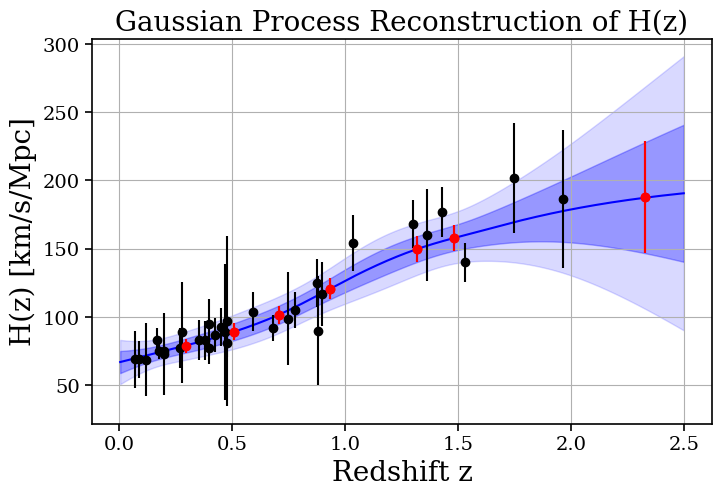

In [11]:
hz_rec_GPR, hz_rec_cov_GPR = gpr.predict_with_uncertainty(z_plot)

plt.figure(figsize=(8,5))
plt.fill_between(z_plot, hz_rec_GPR -  np.sqrt(np.diag(hz_rec_cov_GPR)), hz_rec_GPR + np.sqrt(np.diag(hz_rec_cov_GPR)), alpha=0.3, color='b')
plt.fill_between(z_plot, hz_rec_GPR -  2*np.sqrt(np.diag(hz_rec_cov_GPR)), hz_rec_GPR + 2*np.sqrt(np.diag(hz_rec_cov_GPR)), alpha=0.15, color='b')
plt.plot(z_plot, hz_rec_GPR, color='blue')
plt.errorbar(z_cc, H_obs, yerr=np.sqrt(np.diag(H_cov)), fmt='o', color ='black')
plt.errorbar(z_bao, cc_baomatch_mean_GPR, yerr=np.sqrt(np.diag(cc_baomatch_cov_GPR)), fmt='o', color ='red')
plt.xlabel('Redshift z')
plt.ylabel('H(z) [km/s/Mpc]')
plt.title('Gaussian Process Reconstruction of H(z)')
plt.grid(True)
plt.show()

Integrating 1/H(z) to get DA(z)...


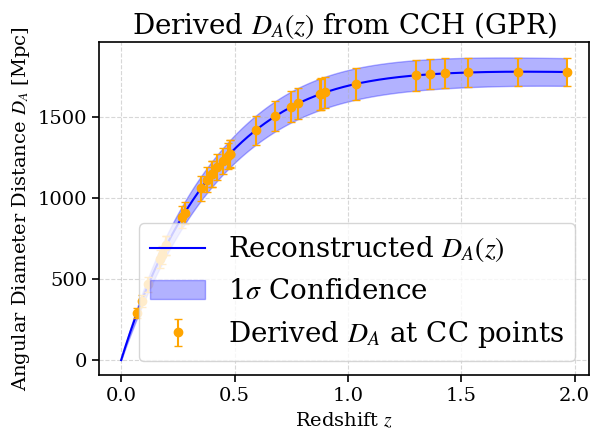

In [12]:
# 这是在从hz中求DL
z_integ = np.linspace(0, np.max(z_cc), 1000)
mu_h_grid, cov_h_grid = gpr.predict_with_uncertainty(z_integ)


N_SAMPLES = 1000
c_light = 299792.458
h_curves = np.random.multivariate_normal(mu_h_grid, cov_h_grid, N_SAMPLES)
da_curves = np.zeros_like(h_curves)

print("Integrating 1/H(z) to get DA(z)...")
for i in range(N_SAMPLES):
    h_path = h_curves[i, :]
    integrand = c_light / h_path
    dc_path = cumulative_trapezoid(integrand, z_integ, initial=0)
    da_curves[i, :] = dc_path / (1 + z_integ)

da_samples_at_cc = np.zeros((N_SAMPLES, len(z_cc)))

for i in range(N_SAMPLES):
    da_samples_at_cc[i, :] = np.interp(z_cc, z_integ, da_curves[i, :])

da_mean = np.mean(da_samples_at_cc, axis=0)
da_cov = np.cov(da_samples_at_cc, rowvar=False)
da_std = np.sqrt(np.diag(da_cov))

np.save('output/da_cc', da_mean)
np.save('output/da_cc_cov', da_cov)

mean_da_curve = np.mean(da_curves, axis=0)
std_da_curve = np.std(da_curves, axis=0)

plt.plot(z_integ, mean_da_curve, color='blue', label=r'Reconstructed $D_A(z)$')
plt.fill_between(z_integ, 
                 mean_da_curve - std_da_curve, 
                 mean_da_curve + std_da_curve, 
                 color='blue', alpha=0.3, label=r'1$\sigma$ Confidence')

plt.errorbar(z_cc, da_mean, yerr=da_std, fmt='o', color='orange', capsize=3, label='Derived $D_A$ at CC points')

plt.xlabel('Redshift $z$', fontsize=14)
plt.ylabel('Angular Diameter Distance $D_A$ [Mpc]', fontsize=14)
plt.title(f'Derived $D_A(z)$ from CCH (GPR)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
#FKM方法
import numpy as np
import pandas as pd
import emcee
from scipy.interpolate import PchipInterpolator
from scipy.optimize import minimize
import utils

np.random.seed(42)

z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)
mask_dm, mask_dh = (bao_type == 'DM_over_rs'), (bao_type == 'DH_over_rs')
z_exclude_dv = z_bao[mask_dh] # BAO nodes
z_unique = np.unique(z_bao)

data = np.loadtxt('data/cc.txt')
z_cc, H_cc = data[:, 0], data[:, 1]
H_cov = np.loadtxt('data/cc_cov.txt')

# --- Configuration ---
z_knots = np.concatenate(([0.0], z_unique)) # [0.0, 0.38, ..., 2.33]
n_dim = len(z_knots)
inv_cc_cov = np.linalg.inv(H_cov)

# 计算一个宽松的 LCDM 理论值作为锚点
# H(z) ~ 70 * E(z)
hz_fiducial = 70.0 * np.sqrt(0.3 * (1 + z_knots)**3 + 0.7)

def log_prior(theta):
    if np.any(theta <= 0): return -np.inf
    if np.any(np.diff(theta) <= 0): return -np.inf
    
    h_last = theta[-1]      # z=2.33
    h_prev = theta[-2]      # z=1.48
    h_prev2 = theta[-3]     # z=0.85
    
    z_last = z_knots[-1]
    z_prev = z_knots[-2]
    z_prev2 = z_knots[-3]
    
    slope_prev = (h_prev - h_prev2) / (z_prev - z_prev2)
    slope_curr = (h_last - h_prev) / (z_last - z_prev)
    
    delta_slope = slope_curr - slope_prev
    sigma_slope = 1.0 * np.abs(slope_prev) + 5.0
    
    lp = -0.5 * (delta_slope / sigma_slope)**2
    
    return lp

def log_likelihood(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp): return -np.inf
    
    # PCHIP 插值
    interp = PchipInterpolator(z_knots, theta)
    model_h = interp(z_cc)
    
    # Chi2 计算
    diff = model_h - H_cc
    chi2 = diff @ inv_cc_cov @ diff
    return -0.5 * chi2 + lp

n_walkers = 32
n_steps = 10000
burn_in = 3000

p0 = hz_fiducial + 5.0 * np.random.randn(n_walkers, n_dim)

print("Running MCMC ...")
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_likelihood)
sampler.run_mcmc(p0, n_steps, progress=True)

flat_samples = sampler.get_chain(discard=burn_in, flat=True)
h_bao_samples = flat_samples[:, 1:] 

hz_mean = np.mean(h_bao_samples, axis=0)
hz_cov = np.cov(h_bao_samples, rowvar=False)

print("\nResult at z=2.33 (Last Node):")
print(f"Mean: {hz_mean[-1]:.2f}, Err: {np.sqrt(hz_cov[-1,-1]):.2f}")
print(f"Fiducial LCDM was: {hz_fiducial[-1]:.2f}")
print(sampler.get_autocorr_time())


Running MCMC ...


  0%|          | 0/10000 [00:00<?, ?it/s]/home/zxw/work/CDDR_Test/.venv/lib/python3.8/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 10000/10000 [00:53<00:00, 187.76it/s]



Result at z=2.33 (Last Node):
Mean: 221.07, Err: 48.04
Fiducial LCDM was: 240.23
[162.56523573 160.74555063 172.36500624 142.15432762 140.38213046
 137.74828045 144.77724626 195.00651198]


<ErrorbarContainer object of 3 artists>

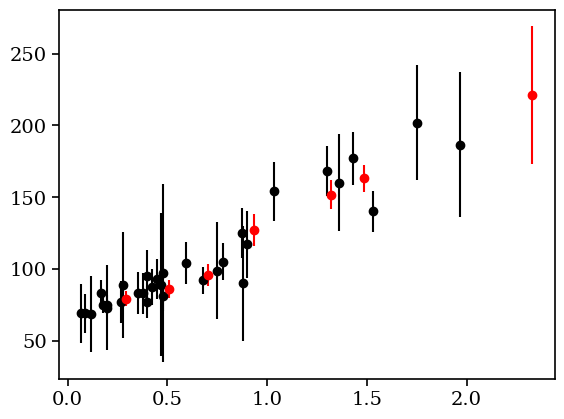

In [14]:
plt.errorbar(z_cc, H_cc, yerr=np.sqrt(np.diag(H_cov)), fmt='o', color ='black')
plt.errorbar(z_unique, hz_mean, yerr=np.sqrt(np.diag(hz_cov)), fmt='o', color ='red')

In [15]:
import numpy as np
import pandas as pd
import emcee
from scipy.interpolate import PchipInterpolator
from scipy.optimize import minimize
import utils

np.random.seed(42)

z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)
mask_dm, mask_dh = (bao_type == 'DM_over_rs'), (bao_type == 'DH_over_rs')
z_exclude_dv = z_bao[mask_dh] # BAO nodes

sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
mB_obs = sn_df['m_b_corr'].values
mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")
inv_mB_cov = np.linalg.inv(mB_cov)

# mask = (sn_df['IS_CALIBRATOR'] == 0) # 去掉了有chephid的样本
# z_sn = sn_df.loc[mask, 'zHD'].values
# mB_obs = sn_df.loc[mask, 'm_b_corr'].values
# idx_sn = sn_df.index[mask].values
# mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")
# mB_cov = mB_cov[np.ix_(idx_sn, idx_sn)]
# inv_mB_cov = np.linalg.inv(mB_cov)

z_knots = np.concatenate(([0.005], z_unique))
m_cp_init = np.interp(z_knots, z_sn, mB_obs)
res = minimize(lambda p: -utils.ln_posterior(p, z_sn, mB_obs, inv_mB_cov, z_knots), m_cp_init, method='L-BFGS-B')
print(res.x)

def log_likelihood(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp): return -np.inf
    
    interp = PchipInterpolator(np.log(z_knots), theta)
    mB_model = interp(np.log(z_sn))
    
    diff = mB_model - mB_obs
    chi2 = diff @ inv_mB_cov @ diff
    return -0.5 * chi2# 加上先验

n_walkers = 32
n_steps = 10000
burn_in = 3000

p0 = res.x + 1e-4  * np.random.randn(n_walkers, n_dim)

print("Running MCMC ...")
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_likelihood)
sampler.run_mcmc(p0, n_steps, progress=True)

flat_samples = sampler.get_chain(discard=burn_in, flat=True)
mB_bao_samples = flat_samples[:, 1:] 

mB_mean_knots = np.mean(mB_bao_samples, axis=0)
mB_cov_knots = np.cov(mB_bao_samples, rowvar=False)

print(sampler.get_autocorr_time())


[12.22627566 21.47002307 22.94797157 23.72507131 24.54717216 25.59026366
 25.7080981  26.89861095]
Running MCMC ...


100%|██████████| 10000/10000 [24:00<00:00,  6.94it/s]


[112.83618095  76.33578082  82.8972289   80.96336078  88.11978937
  88.83541845 102.6903345   86.67205061]


<ErrorbarContainer object of 3 artists>

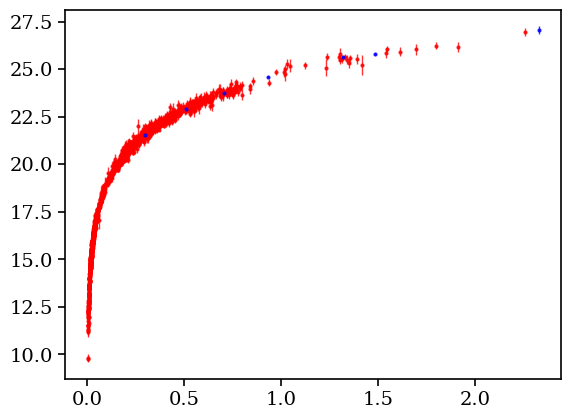

In [16]:
plt.errorbar(z_sn, mB_obs, yerr=np.sqrt(np.diag(mB_cov)),fmt='o', capsize=0, ms=2, elinewidth=1, color='red', alpha=0.8)
plt.errorbar(z_unique, mB_mean_knots, yerr=np.sqrt(np.diag(mB_cov_knots)),fmt='o', capsize=0, ms=2, elinewidth=1, color='blue', alpha=0.8)

In [17]:
import numpy as np

# 1. 映射逻辑：将 unique 节点重构结果映射回原始 BAO 数据长度
z_raw = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', usecols=0)
mask = np.isin(np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', usecols=2, dtype=str), ['DM_over_rs', 'DV_over_rs', 'DH_over_rs'])
z_fit = z_raw[mask]
z_unique = np.unique(z_fit)

# 找到原始红移在 unique 节点中的索引
idx = np.searchsorted(z_unique, z_fit)
# 构建投影矩阵 P (N_fit x M_unique)
P = np.eye(len(z_unique))[idx]

# 2. 处理并存储 CC (H)
# 去掉锚点 z=0
h_mu, h_cv = np.mean(h_bao_samples, axis=0), np.cov(h_bao_samples, rowvar=False)

cc_mean_fkm = h_mu[idx]
cc_cov_fkm = P @ h_cv @ P.T

np.save('output/cc_baomatch_mean_FKM.npy', cc_mean_fkm)
np.save('output/cc_baomatch_cov_FKM.npy', cc_cov_fkm)

# 3. 处理并存储 SN (mB)
# 去掉锚点 z=0.005
mb_mu, mb_cv = np.mean(mB_bao_samples, axis=0), np.cov(mB_bao_samples, rowvar=False)

mb_mean_fkm = mb_mu[idx]
mb_cov_fkm = P @ mb_cv @ P.T

np.save('output/mB_baomatch_mean_FKM.npy', mb_mean_fkm)
np.save('output/mB_baomatch_cov_FKM.npy', mb_cov_fkm)

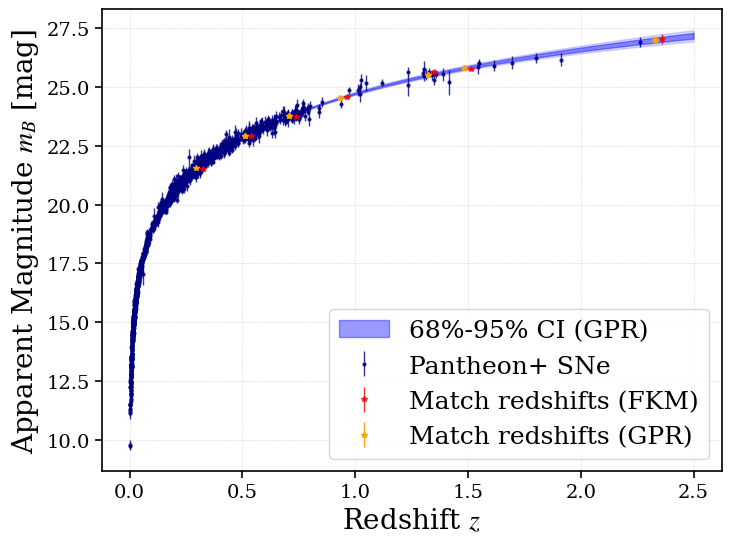

In [20]:
# plot
plt.figure(figsize=(8, 6))
plt.errorbar(z_sn, mB_obs, yerr=np.sqrt(np.diag(mB_cov)), fmt='o', label='Pantheon+ SNe', capsize=0, ms=2, elinewidth=1, color='navy', alpha=0.8)
plt.errorbar(z_unique+0.03, mB_mean_knots, yerr=np.sqrt(np.diag(mB_cov_knots)), capsize=0, ms=4, elinewidth=1, fmt='*', color='red', alpha=0.8, label='Match redshifts (FKM)')
plt.errorbar(z_bao, mB_baomatch_mean, yerr=np.sqrt(np.diag(mB_baomatch_cov)),  capsize=0, ms=4, elinewidth=1, fmt='*', color='orange', label='Match redshifts (GPR)')
plt.fill_between(z_plot, mB_rec_GPR - np.sqrt(np.diag(mB_rec_GPR_cov)), mB_rec_GPR + np.sqrt(np.diag(mB_rec_GPR_cov)), color='blue', alpha=0.4,  label='68%-95% CI (GPR)')
plt.fill_between(z_plot, mB_rec_GPR - 2*np.sqrt(np.diag(mB_rec_GPR_cov)), mB_rec_GPR + 2*np.sqrt(np.diag(mB_rec_GPR_cov)), color='blue', alpha=0.15)
plt.xlabel('Redshift $z$')
plt.ylabel(r'Apparent Magnitude $m_B$ [mag]')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.legend(loc='best', frameon=True, fontsize=18)
plt.savefig('fig/mB_reconstruction.pdf', bbox_inches='tight')
plt.show()

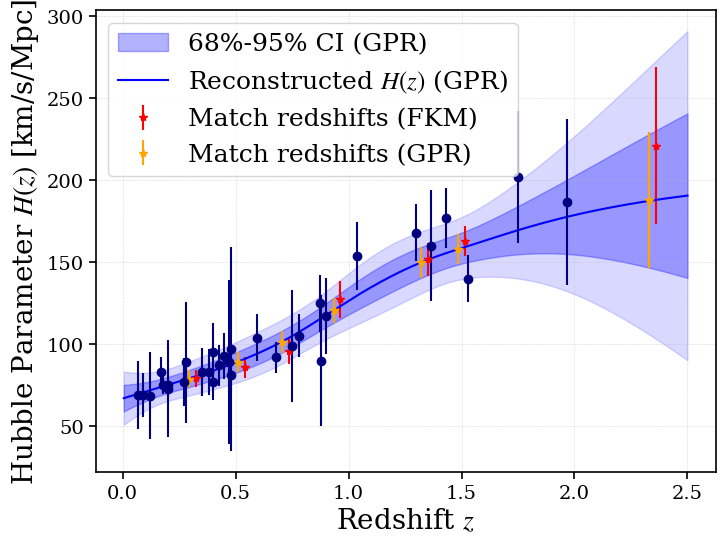

In [24]:
plt.figure(figsize=(8,6))
plt.errorbar(z_unique+0.03, hz_mean, yerr=np.sqrt(np.diag(hz_cov)), fmt='*', color ='red', label='Match redshifts (FKM)')
plt.errorbar(z_bao, cc_baomatch_mean_GPR, yerr=np.sqrt(np.diag(cc_baomatch_cov_GPR)), fmt='*', color ='orange', label='Match redshifts (GPR)')
plt.fill_between(z_plot, hz_rec_GPR -  np.sqrt(np.diag(hz_rec_cov_GPR)), hz_rec_GPR + np.sqrt(np.diag(hz_rec_cov_GPR)), alpha=0.3, color='b',  label='68%-95% CI (GPR)')
plt.fill_between(z_plot, hz_rec_GPR -  2*np.sqrt(np.diag(hz_rec_cov_GPR)), hz_rec_GPR + 2*np.sqrt(np.diag(hz_rec_cov_GPR)), alpha=0.15, color='b')
plt.plot(z_plot, hz_rec_GPR, color='blue', label='Reconstructed $H(z)$ (GPR)')
plt.errorbar(z_cc, H_obs, yerr=np.sqrt(np.diag(H_cov)), fmt='o', color ='navy')
plt.xlabel('Redshift $z$')
plt.ylabel('Hubble Parameter $H(z)$ [km/s/Mpc]')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.legend(loc='best', frameon=True,fontsize=18)
plt.savefig('fig/Hz_reconstruction.pdf', bbox_inches='tight')
plt.show()